**NIFTY50 HYPERPARAMETER TUNING - OPEN PRICE**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --- 1. Data Prep Function (From your previous code) ---
def prep_raw_data_for_open(raw_data):
    df = raw_data.copy()
    df["Target"] = df["Open"].shift(-1)
    feature_cols = ["Open", "High", "Low", "Close", "Volume"]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    clean_df = df[feature_cols + ["Target"]].dropna()
    return clean_df[feature_cols], clean_df["Target"]

# --- 2. Configuration ---
ticker = "^NSEI"
end_date = "2026-06-01"
horizons = {
    "5_Years": "2021-06-01",
    "10_Years": "2016-06-01",
    "20_Years": "2006-06-01"
}


In [3]:
# --- 3. Hyperparameter Grids ---
# We use shallow depths and high regularization to combat the massive overfitting you experienced.
param_grids = {
    "RandomForest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7, 10], # Keep trees shallow
        "model__min_samples_split": [5, 10, 20],
        "model__min_samples_leaf": [2, 5, 10]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 500],
        "model__max_depth": [3, 5, 7], # Shallow depth
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__reg_alpha": [0.1, 1.0, 10.0],  # L1 regularization
        "model__reg_lambda": [1.0, 10.0, 50.0] # L2 regularization (Crucial for trending data)
    }
}

models_to_tune = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror')
}

In [4]:

# --- 4. Tuning Execution ---
print("Starting Hyperparameter Tuning with TimeSeriesSplit...\n")

# TimeSeriesSplit ensures we don't leak future data during cross-validation
tscv = TimeSeriesSplit(n_splits=5)
tuned_results = []

raw_data = yf.download(ticker, start="2005-01-01", end=end_date, progress=False)

for horizon_name, start_date in horizons.items():
    print(f"========== Horizon: {horizon_name.replace('_', ' ')} ==========")
    horizon_raw = raw_data.loc[start_date:end_date]
    X, y = prep_raw_data_for_open(horizon_raw)
    
    # 80/20 Chronological Split
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    
    for model_name, model in models_to_tune.items():
        print(f"Tuning {model_name}...")
        
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        
        # RandomizedSearchCV tests 15 random combinations from the grid to save time
        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_grids[model_name],
            n_iter=15, 
            cv=tscv, 
            scoring='r2',
            n_jobs=-1, # Use all CPU cores
            random_state=42,
            verbose=0
        )
        
        # Fit the search
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        
        # Predict with the best model
        train_pred = best_model.predict(X_train)
        test_pred = best_model.predict(X_test)
        
        # Record metrics
        tuned_results.append({
            "Horizon": horizon_name,
            "Model": model_name,
            "Best_Params": str(search.best_params_),
            "Train_R2": round(r2_score(y_train, train_pred), 4),
            "Test_R2": round(r2_score(y_test, test_pred), 4),
            "Test_RMSE": round(np.sqrt(mean_squared_error(y_test, test_pred)), 2)
        })

Starting Hyperparameter Tuning with TimeSeriesSplit...

========== Horizon: 5 Years ==========
Tuning RandomForest...
Tuning XGBoost...
========== Horizon: 10 Years ==========
Tuning RandomForest...
Tuning XGBoost...
========== Horizon: 20 Years ==========
Tuning RandomForest...
Tuning XGBoost...


In [5]:
# --- 5. Display Results ---
tuned_results_df = pd.DataFrame(tuned_results)
print(" Tuning Complete! Here are the optimized non-linear models:")
display(tuned_results_df[["Horizon", "Model", "Train_R2", "Test_R2", "Test_RMSE"]])


 Tuning Complete! Here are the optimized non-linear models:


,Horizon,Model,Train_R2,Test_R2,Test_RMSE
0,5_Years,RandomForest,0.9995,0.9547,183.70
1,5_Years,XGBoost,0.9998,0.9435,205.05
2,10_Years,RandomForest,0.9999,-2.5985,1886.44
3,10_Years,XGBoost,0.9999,-3.0736,2007.12
4,20_Years,RandomForest,0.9999,-1.6847,4708.72
5,20_Years,XGBoost,0.9999,-1.8534,4854.38


In [6]:

# If you want to see the exact hyperparameters it chose, you can print them:
for index, row in tuned_results_df.iterrows():
    print(f"Best params for {row['Model']} ({row['Horizon']}):\n{row['Best_Params']}")

Best params for RandomForest (5_Years):
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
Best params for XGBoost (5_Years):
{'model__reg_lambda': 1.0, 'model__reg_alpha': 10.0, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05}
Best params for RandomForest (10_Years):
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
Best params for XGBoost (10_Years):
{'model__reg_lambda': 1.0, 'model__reg_alpha': 10.0, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05}
Best params for RandomForest (20_Years):
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
Best params for XGBoost (20_Years):
{'model__reg_lambda': 1.0, 'model__reg_alpha': 10.0, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05}


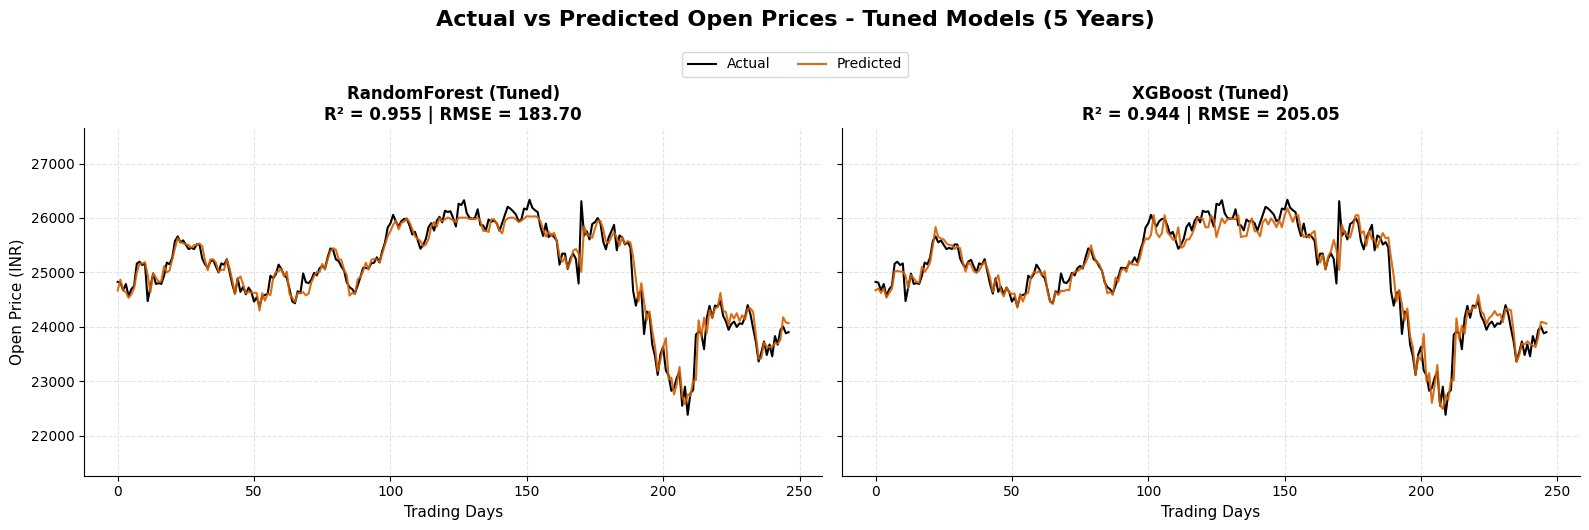

In [7]:
def plot_tuned_actual_vs_predicted(ticker="^NSEI"):
    """
    Re-runs the best parameters to plot Actual vs Predicted lines 
    for the 5-Year Horizon (as an example of the best extrapolation).
    """
        
    # Isolate the 5-Year data
    start_date = horizons["5_Years"]
    horizon_raw = raw_data.loc[start_date:end_date]
    X, y = prep_raw_data_for_open(horizon_raw)
    
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    
    # Extract the best models from your tuning results DataFrame
    best_rf_params = eval(tuned_results_df[(tuned_results_df['Horizon'] == '5_Years') & (tuned_results_df['Model'] == 'RandomForest')]['Best_Params'].values[0])
    best_xgb_params = eval(tuned_results_df[(tuned_results_df['Horizon'] == '5_Years') & (tuned_results_df['Model'] == 'XGBoost')]['Best_Params'].values[0])
    
    # Strip the "model__" prefix used in the pipeline
    best_rf_params = {k.replace('model__', ''): v for k, v in best_rf_params.items()}
    best_xgb_params = {k.replace('model__', ''): v for k, v in best_xgb_params.items()}
    
    # Re-train with exact best parameters
    rf_model = Pipeline([("scaler", StandardScaler()), ("model", RandomForestRegressor(random_state=42, **best_rf_params))])
    xgb_model = Pipeline([("scaler", StandardScaler()), ("model", XGBRegressor(random_state=42, objective='reg:squarederror', **best_xgb_params))])
    
    rf_model.fit(X_train, y_train)
    xgb_model.fit(X_train, y_train)
    
    preds_dict = {
        "RandomForest (Tuned)": rf_model.predict(X_test),
        "XGBoost (Tuned)": xgb_model.predict(X_test)
    }
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(f"Actual vs Predicted Open Prices - Tuned Models (5 Years)", fontsize=16, fontweight='bold', y=1.05)
    
    global_min, global_max = min(y_test), max(y_test)
    
    for i, (model_name, y_pred) in enumerate(preds_dict.items()):
        ax = axes[i]
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        ax.plot(y_test.values, color="black", linewidth=1.5, label="Actual")
        ax.plot(y_pred, color="#D55E00", linewidth=1.5, alpha=0.9, label="Predicted")
        
        ax.set_ylim(global_min * 0.95, global_max * 1.05)
        ax.set_title(f"{model_name}\nR² = {r2:.3f} | RMSE = {rmse:.2f}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.35)
        sns.despine(ax=ax)
        
        if i == 0: ax.set_ylabel("Open Price (INR)", fontsize=11)
        ax.set_xlabel("Trading Days", fontsize=11)
            
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=2, frameon=True)
    plt.tight_layout()
    plt.show()

# Execute Line Charts
plot_tuned_actual_vs_predicted()